In [21]:
from Scope.Read_Write import load_binary

In [22]:
## Loads the System object from a binary file, provided in the tutorial folder
sys = load_binary('/Users/sergivela/Documents/SCOPE/Program/Scope_New/tutorials/Sources/ABITEM.npy')
## All objects in SCOPE have a __repr__ method, so printing shows a summary of the object
print(sys)

-------------------------------------
-- >>> SCOPE SCO-System Object >>> --
-------------------------------------
 Version               = 1.0
 Type                  = system
 Subtype               = sco_system
 Name                  = ABITEM
 Source Path           = /Users/sergivela/Documents/SCOPE/Database_SCO/4-Merged/ABITEM/
 Calculations Path     = /Users/sergivela/Documents/SCOPE/Database_SCO/Test_V1/Calcs/ABITEM/
 System File Path      = /Users/sergivela/Documents/SCOPE/Database_SCO/Test_V1/Systems/ABITEM/

 # of Sources          = 6
     idx, type, name, formula               
     0: cell ABITEM01 H104-C92-N24-O4-S8-Fe4 
     1: cell ABITEM H104-C92-N24-O4-S8-Fe4 
     2: cell ref_hs_cell H104-C92-N24-O4-S8-Fe4 
     3: cell ref_ls_cell H104-C92-N24-O4-S8-Fe4 
     4: specie ref_hs_mol H18-C20-N6-S2-Fe 
     5: specie ref_ls_mol H18-C20-N6-S2-Fe 




In [3]:
sou = sys.sources[0]
sou

-----------------------------------
-- >>> SCOPE SCO-CELL Object >>> --
-----------------------------------
 Version               = 1.0
 Type                  = cell
 Name                  = ABITEM01
 Num Atoms             = 236
 Cell Parameters a:c   = [12.134, 11.987, 16.925]
 Cell Parameters al:ga = [90.0, 90.137, 90.0]
 # Molecules:          = 8
 With Formulae:                               
    0: H18-C20-N6-S2-Fe 
    1: H18-C20-N6-S2-Fe 
    2: H8-C3-O 
    3: H8-C3-O 
    4: H8-C3-O 
    5: H8-C3-O 
    6: H18-C20-N6-S2-Fe 
    7: H18-C20-N6-S2-Fe 
-------------------------------
 # of Ref Molecules:   = 2
 With Formulae:                                  
    0: H18-C20-N6-S2-Fe 
    1: H8-C3-O 
 Phase                 = LS
 HS Molar Fraction     = 0.0


In [4]:
sou.path

'/Users/sergivela/Documents/SCOPE/Database_SCO/4-Merged/ABITEM/ABITEM01/Cell_ABITEM01.gmol'

In [1]:
from Scope.Read_Write import load_binary
old_cell = load_binary('/Users/sergivela/Documents/SCOPE/Database_SCO/4-Merged/ABITEM/ABITEM01/Cell_ABITEM01.gmol')

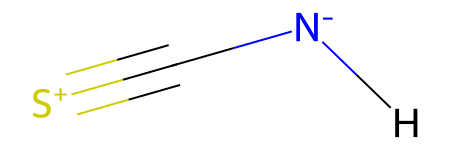

In [2]:
lig = old_cell.moleclist[0].ligandlist[0]
lig.object

In [3]:
for idx, rdkit_atom in enumerate(lig.object.GetAtoms()):
    neig = rdkit_atom.GetNeighbors()
    for jdx, at2 in enumerate(neig):
        print(f"{idx=} {jdx=} {at2.GetSymbol()} {at2.GetIdx()}")

idx=0 jdx=0 C 2
idx=1 jdx=0 C 2
idx=1 jdx=1 H 3
idx=2 jdx=0 S 0
idx=2 jdx=1 N 1
idx=3 jdx=0 N 1


In [4]:
lig.atoms[0].charge


1

In [5]:
mol = old_cell.moleclist[0]

In [4]:
lig.totcharge

-1

In [5]:
lig.atcharge

[1, -2, 0]

In [6]:
for idx, rdkit_atom in enumerate(lig.object.GetAtoms()):
    print(f"\t{idx=}", rdkit_atom.GetSymbol(), rdkit_atom.GetFormalCharge())

	idx=0 S 1
	idx=1 N -1
	idx=2 C 0
	idx=3 H 0


In [6]:
from Scope.Classes_Specie import import_ligand
from Scope.Classes_Cell   import import_cell
imported_cell   = import_cell(old_cell, debug=1)

IMPORT CELL: importing cell -------------------------------
   >>> SCOPE CELL Object >>>   
-------------------------------
 Version               = 1.0
 Type                  = cell
 Name                  = ABITEM01
 Num Atoms             = 236
 Cell Parameters a:c   = [12.134, 11.987, 16.925]
 Cell Parameters al:ga = [90.0, 90.137, 90.0]
-------------------------------


IMPORT CELL: creating moleclist
IMPORT MOLEC: importing molecule H18-C20-N6-S2-Fe
SPECIE.ADD_PARENT: added parent with subtype=cell. Indices are [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46]
IMPORT MOLEC: parent parent.subtype='cell' added with indices=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46]
IMPORT MOLEC: importing atoms from old_molecule
IMPORT ATOM

In [7]:
imported_ligand = imported_cell.moleclist[0].ligands[0]

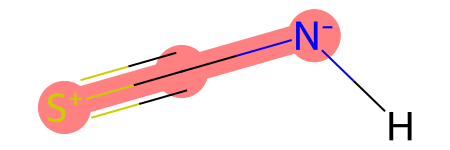

In [8]:
imported_ligand.old_rdkit_obj

In [9]:
for idx, rdkit_atom in enumerate(imported_ligand.old_rdkit_obj.GetAtoms()):
    print(f"\t{idx=}", rdkit_atom.GetSymbol(), rdkit_atom.GetFormalCharge())

	idx=0 S 1
	idx=1 N -1
	idx=2 C 0
	idx=3 H 0


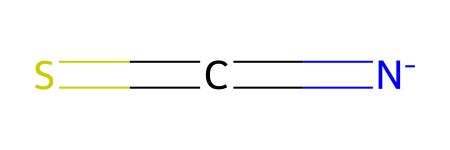

In [ ]:
imported_ligand.rdkit_obj

In [11]:
for idx, rdkit_atom in enumerate(imported_ligand.rdkit_obj.GetAtoms()):
    print(f"\t{idx=}", rdkit_atom.GetSymbol(), rdkit_atom.GetFormalCharge())

	idx=0 S 0
	idx=1 N -1
	idx=2 C 0


In [16]:
mol = imported_cell.moleclist[0]
print(mol)

--------------------------------------------------
------------- SCOPE MOLECULE Object --------------
--------------------------------------------------
 Version               = 1.0
 Type                  = specie
 Sub-Type              = molecule
 Number of Atoms       = 47
 Formula               = H18-C20-N6-S2-Fe
 Number of Parents     = 1
 Total Charge          = 0
 SMILES                = ['[N-]=C=S', '[H]c1nc(C([H])([H])N(C([H])([H])c2nc([H])c([H])c([H])c2[H])C([H])([H])c2nc([H])c([H])c([H])c2[H])c([H])c([H])c1[H]', '[N-]=C=S']
 Has Adjacency Matrix  = YES
 Has Bonds             = YES
 # Ligands             = 3
 # Metals              = 1




In [20]:
for lig in mol.ligands:
    print(lig.totcharge, lig.atomic_charges)

for met in mol.metals:
    print(met.charge)

-1 [0, -1, 0]
0 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
-1 [0, -1, 0]
2


In [14]:
for at in imported_ligand.atoms:
    print(at.label, at.charge)

S 0
N 0
C 0


In [15]:
imported_ligand.atomic_charges

[0, 0, 0]

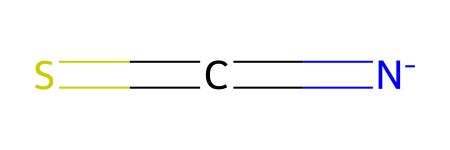

In [21]:
sys = load_binary('./Sources/ABITEM.npy')
sou = sys.sources[0]
mol = sou.moleclist[0]
lig = mol.ligands[0]
lig.rdkit_obj

In [11]:
lig

------------------------------------------------
------------- SCOPE LIGAND Object --------------
------------------------------------------------
 Version               = 1.0
 Type                  = specie
 Sub-Type              = ligand
 Number of Atoms       = 3
 Formula               = C-N-S
 Number of Parents     = 2
 Total Charge          = -1
 SMILES                = [N-]=C=S
 Has Adjacency Matrix  = NO 
 Has Bonds             = YES
 # HAS RDKIT OBJECT    = YES


In [20]:
lig.atomic_charges

[1, -2, 0]

In [21]:
lig.totcharge

-1

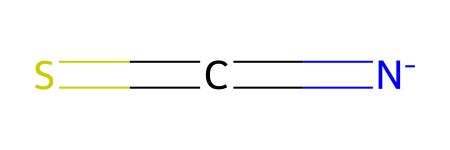

In [22]:
lig.rdkit_obj

In [24]:
for at in lig.atoms:
    print(at.charge)

0
0
0
